## **Business Problem** ##
A global e-commerce company operating across multiple regions manages end-to-end order filfilment, including shipping and delvery, for products  like sporting goods. The company is facing inconsistent delivery performance, where actual shipping items often deviate from scheduled and delivery, leading to late deliveries and unpredictable order profitablity.

## Desired Outcome ##
The goal is to analysze delivery operations, identify bottlenecks, and build a predictive system to reduce delays, optimize shipping decisions, and improve overall profitablity and efficiency.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')


In [3]:
#Set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

Explanation about setting the color theme code 
cm.viridis is the viridis colormap — a perceptually uniform gradient from dark purple → green → yellow.
np.linspace(0, 1, 5) generates 5 evenly spaced numbers between 0 and 1 → [0, 0.25, 0.5, 0.75, 1.0]
Passing this array into cm.viridis(...) samples 5 colors at those exact points along the gradient, evenly spaced from one end to the other.
The result is an array of 5 RGBA color values (each like (R, G, B, A), with values from 0 to 1).

In [4]:
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

## Exploratory Data ANalysis (EDA) ##

In [5]:
#overview
print('rows, cols', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum dulicates:', df.duplicated().sum())
print('\nMissing vales (top 20):')
print(df.isna().sum().sort_values(ascending=False))


rows, cols (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product

## Data Cleaning ##

In [6]:
#Drop columns which are not useful
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Product Category Id',
    'Benefit per order', #identical to order profit per order
    'Product Status',
    'Customer City',
    'Order City',
    'Order Country',
    'Customer State',
    'Market'
    ]


#dropping columns that are either fully missing, redundant, or have only one value
df = df.drop(columns=columns_to_drop)

#removing canceled orders since they are not relevant for delivery time analysis
df = df[df['Delivery Status'] != 'SHipping canceled']

#standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

#after data cleaning, let's check the overview again to see how the dataset has changed
print('rows, cols:', df.shape)
print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (180519, 23)

Missing values (top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [7]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [7]:
#value counts for categoricalcolumns with low cardinality
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col} value counts:')
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    107752
2     35216
1     27814
0      9737
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Order Status value c

In [8]:
#calculating order processing time and delay

df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()


,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,Customer Id,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Card Id,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,183.107609,0.548291,6691.379495,2016-06-12 17:47:04.669868,0.120647,203.772096,21.974989,692.509764,141.232550,2016-06-16 05:45:23.202433,3.471856,0.540010,6.235449,11.483689
min,0.000000,0.000000,7.490000,0.000000,1.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,19.000000,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,3258.500000,2015-09-21 13:49:00,0.080000,119.980003,7.000000,403.000000,50.000000,2015-09-25 06:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,6457.000000,2016-06-11 13:06:00,0.270000,199.919998,31.520000,627.000000,59.990002,2016-06-15 08:32:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,9779.000000,2017-03-01 08:42:00,0.360000,299.950012,64.800003,1004.000000,199.990005,2017-03-04 21:29:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,20757.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1363.000000,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623722,1.374449,120.043670,0.497664,4162.918106,NaN,0.466796,132.273077,104.433526,336.446807,139.732492,NaN,1.670471,1.491881,3.403571,6.923006


In [9]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     98743
False    81776
Name: count, dtype: int64

In [15]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Id', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order State',
       'Order Status', 'Product Card Id', 'Product Name', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode', 'Order Processing Time',
       'Delay', 'Is_Delayed', 'order_month', 'order_day', 'order_hour'],
      dtype='str')

In [10]:
#profitability flag based on order profit per order
df['Profitability Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit',
                             np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break-even'))
df['Profitability Flag'].value_counts()

Profitability Flag
Profit        145558
Loss           33784
Break-even      1177
Name: count, dtype: int64

In [17]:
df['Profitability Flag'].value_counts(normalize=True)

Profitability Flag
Profit        0.806331
Loss          0.187149
Break-even    0.006520
Name: proportion, dtype: float64

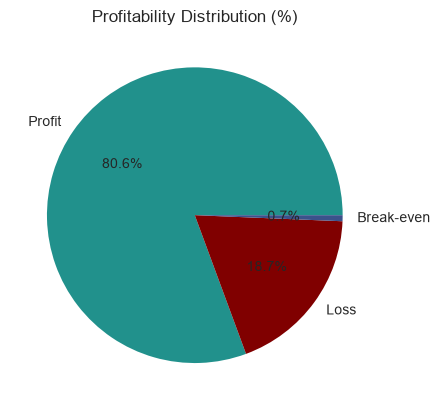

In [11]:
#visualize
profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=[accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [12]:
# --- Safety check: recreate dependent columns if missing ---
if 'Order Processing Time' not in df.columns:
    df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days

if 'Delay' not in df.columns:
    df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']

if 'Order Profit Per Order' not in df.columns:
    # check for common naming variants
    possible = [c for c in df.columns if 'profit' in c.lower()]
    print("Profit-related columns found:", possible)

# --- creating kpi ---
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\n--- Business KPIs ---\n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 180519
Late Deliveries: 98743
90% Delay (days): 3.00
On time Delivery %: 45.30
Late Delivery %: 54.70
Total Profit: 7.9M $
Total Loss due to delays: 2.1M $


## Profitability Vs Delivery Time Analysis ##

In [15]:
profit_metrix = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        mean_profit='mean',
        total_profit='sum',
        order_count='count',
    )
    .reset_index()
)
profit_metrix

,Delay,mean_profit,total_profit,order_count
0,-2,23.423528,5.074942e+05,21666
1,-1,21.516997,4.669188e+05,21700
2,0,22.044854,8.467429e+05,38410
3,1,22.225592,1.244411e+06,55990
4,2,21.246239,6.101495e+05,28718
5,3,19.941130,1.406248e+05,7052
6,4,21.561202,1.505619e+05,6983


In [13]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()
delay_distribution

,Delay,proportion
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291


/nProfit Metrics by delay day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,507494.2,21666
1,-1,21.5,466918.8,21700
2,0,22.0,846742.9,38410
3,1,22.2,1244410.9,55990
4,2,21.2,610149.5,28718
5,3,19.9,140624.8,7052
6,4,21.6,150561.9,6983


/nDelay Distribution (%):


,Delay_Days,Percentage
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291


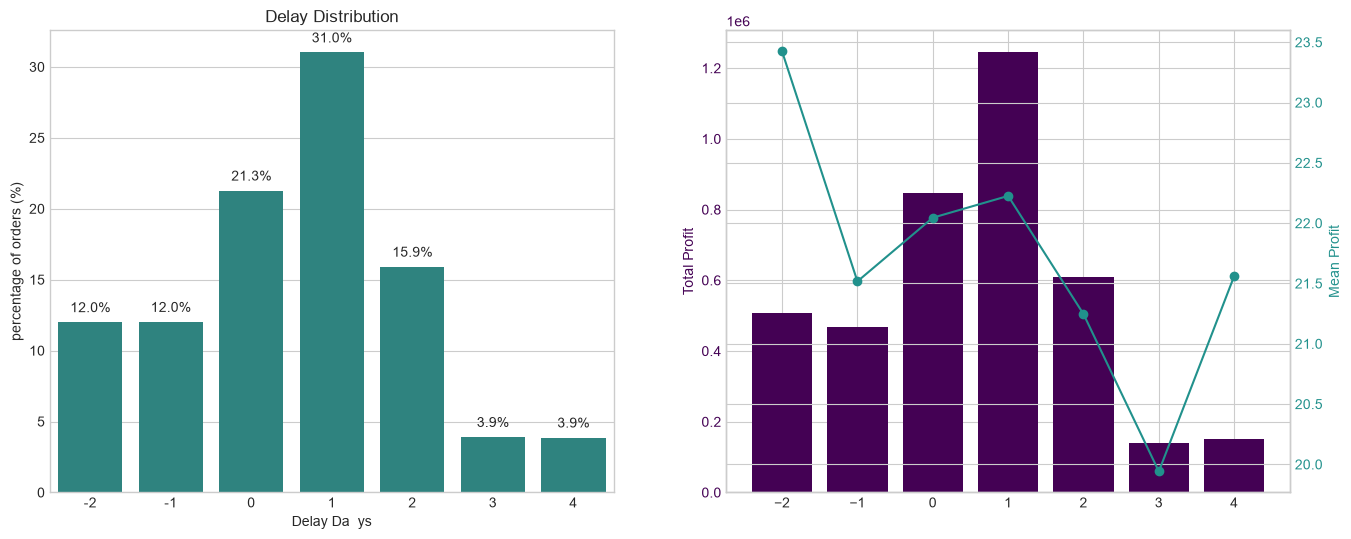

In [16]:
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("/nProfit Metrics by delay day:")
display(profit_metrix.round(1))

print("/nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots                   (1,2,figsize=(16,6))

#first subplot: delay distribution 
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay Da  ys')
ax1.set_ylabel('percentage of orders (%)')

#percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom')

#second subplot: profit analysis by delay days
ax2.set_ylabel("Total Profit", color=primary_color)
ax2.bar(profit_metrix['Delay'], profit_metrix['total_profit'], color=primary_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor= primary_color)

ax3 = ax2.twinx()

ax3.set_xlabel("Delaay Days")
ax3.set_ylabel("Mean Profit", color= accent_color)
ax3.plot(profit_metrix['Delay'], profit_metrix['mean_profit'], marker='o', label='Mean Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)  

## Bottleneck Detection ##

In [17]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False). head(10)
    return cat_df



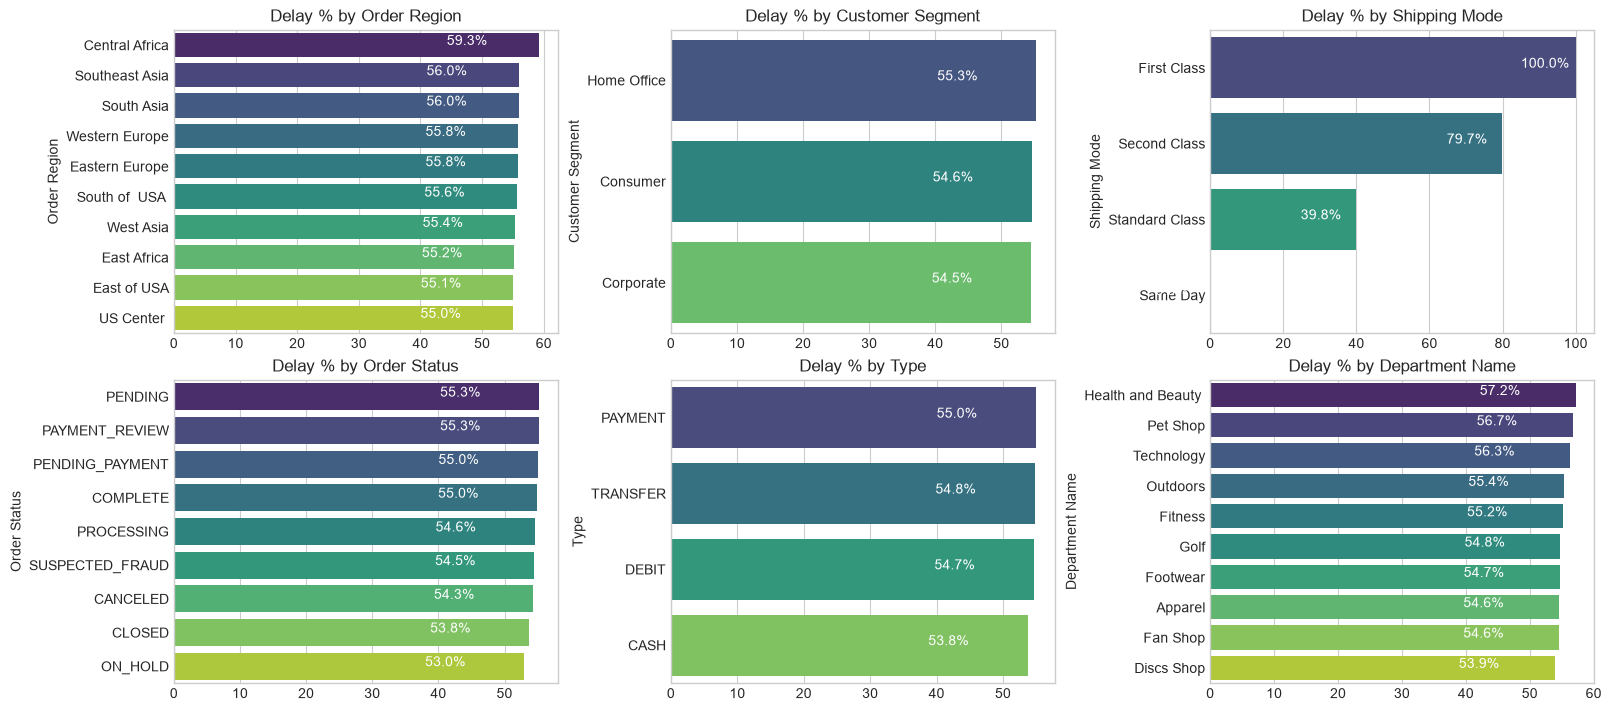

In [18]:
categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    # Safety check: does the column exist at all?
    if category not in df.columns:
        ax.set_title(f'{category}: column not found')
        ax.axis('off')
        continue

    try:
        cat_df = compute_delay_pct_by_category(category)
    except Exception as e:
        ax.set_title(f'{category}: error')
        ax.text(0.5, 0.5, str(e), ha='center', va='center', fontsize=8, wrap=True)
        ax.axis('off')
        continue

    # Safety check: is the result empty?
    if cat_df is None or cat_df.empty:
        ax.set_title(f'{category}: no data')
        ax.axis('off')
        continue

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        hue=category,
        palette='viridis',
        legend=False
    )
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)

    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f"{row['delay_pct']:.1f}%", fontsize=10, color='white')

plt.show()

## Root Cause Analysis ##

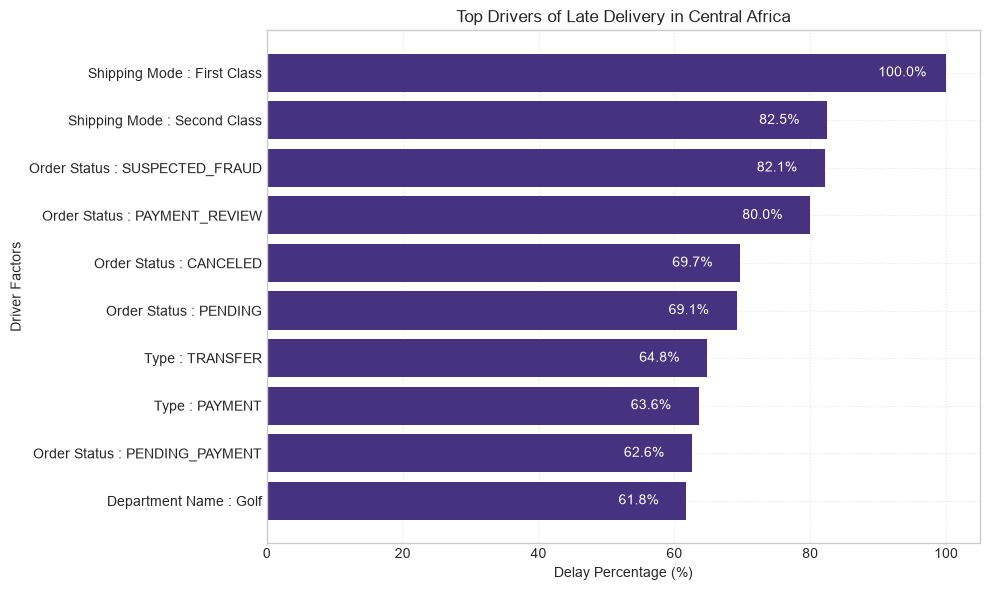

,Driver,Factor_Level,delay_pct,avg_delay,total_orders
0,Shipping Mode,Shipping Mode : First Class,100.000000,1.000000,300
1,Shipping Mode,Shipping Mode : Same Day,0.000000,0.000000,79
2,Shipping Mode,Shipping Mode : Second Class,82.491582,2.127946,297
3,Shipping Mode,Shipping Mode : Standard Class,44.855145,0.116883,1001
0,Customer Segment,Customer Segment : Consumer,60.848485,0.664242,825
1,Customer Segment,Customer Segment : Corporate,58.211679,0.481752,548
2,Customer Segment,Customer Segment : Home Office,56.907895,0.779605,304
0,Department Name,Department Name : Apparel,57.777778,0.624444,450
1,Department Name,Department Name : Fan Shop,58.685446,0.600939,639
2,Department Name,Department Name : Fitness,54.166667,0.166667,24


In [20]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']

    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']])

    # combine all drivers
    final_df = pd.concat(all_factors)

    # top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)

    # plot
    plt.figure(figsize=(10, 6))
    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()
        label_x = width - 10 if width > 15 else width + 1
        plt.text(label_x, bar.get_y() + bar.get_height()/2,
                  f"{width:.1f}%",
                  va='center', fontsize=10, color='white' if width > 15 else 'black')

    plt.tight_layout()
    plt.show()

    return final_df


top_drivers_for_region('Central Africa')

## Time Based ANalysis ##

In [22]:
df['shipping date (DateOrders)'].max()

Timestamp('2018-02-06 22:14:00')

In [ ]:
#Delay  % by Month, Day of Week, Hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)

delay_by_hour = ( 
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

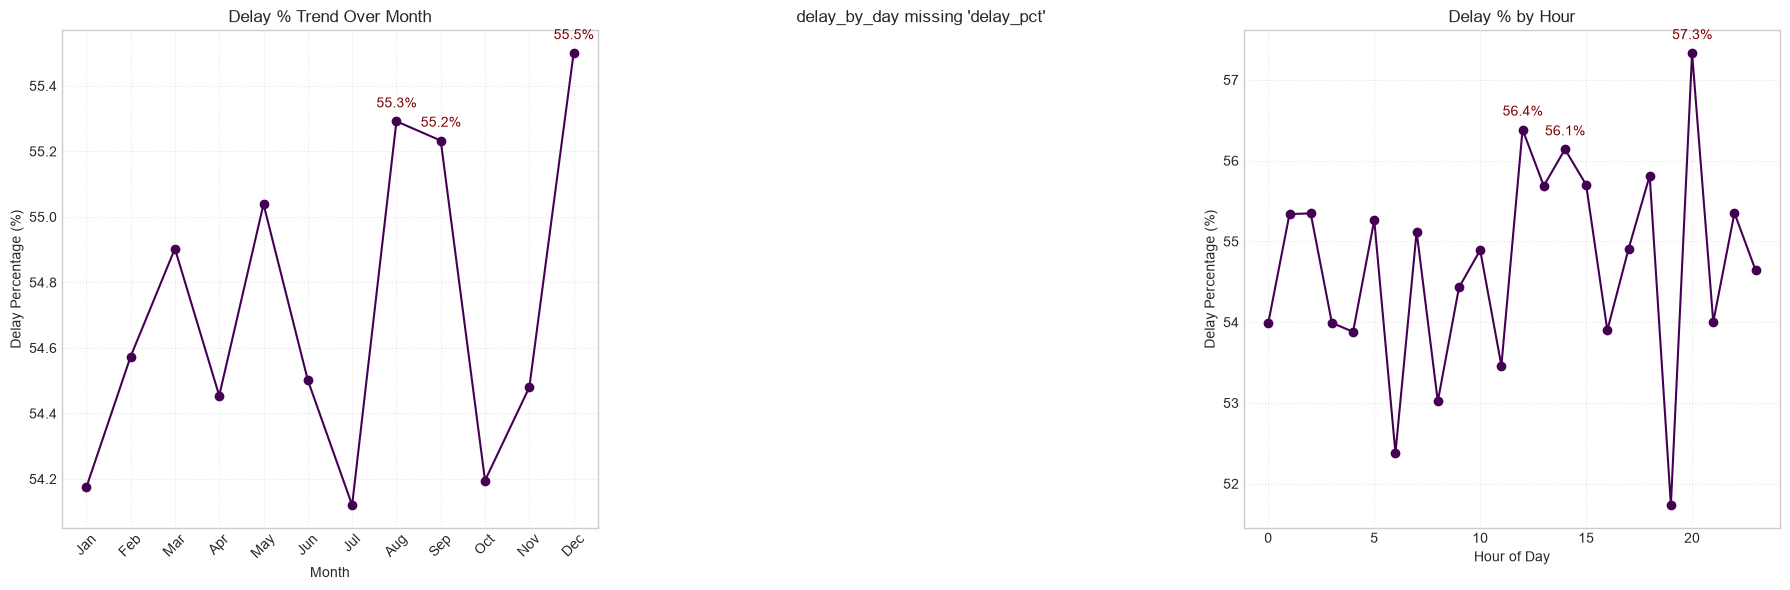

In [30]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# ---------- Subplot 1: Delay % Trend Over Month ----------
if 'delay_pct' not in delay_by_month.columns:
    ax1.set_title("delay_by_month missing 'delay_pct'")
    ax1.axis('off')
else:
    ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
    ax1.set_xticks(range(1, 13))
    ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Delay Percentage (%)")
    ax1.set_title("Delay % Trend Over Month")
    ax1.grid(True, linestyle=':', alpha=0.5)

    top3_month = delay_by_month.nlargest(3, 'delay_pct')
    for _, row in top3_month.iterrows():
        ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                     textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

# ---------- Subplot 2: Delay % by Day of Week ----------
delay_by_day = delay_by_day.copy()  # avoid SettingWithCopyWarning / silent failures

if 'delay_pct' not in delay_by_day.columns:
    ax2.set_title("delay_by_day missing 'delay_pct'")
    ax2.axis('off')
elif 'order_day' not in delay_by_day.columns:
    ax2.set_title("delay_by_day missing 'order_day'")
    ax2.axis('off')
else:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
    delay_by_day = delay_by_day.sort_values('order_day')

    ax2.bar(delay_by_day['order_day'].astype(str), delay_by_day['delay_pct'], color=primary_color)
    ax2.set_xticklabels(delay_by_day['order_day'].astype(str), rotation=45)
    ax2.set_xlabel("Day of Week")
    ax2.set_ylabel("Delay Percentage")
    ax2.set_title("Delay % by Day of Week")
    ax2.grid(True, linestyle=':', alpha=0.5)

    top3_day = delay_by_day.nlargest(3, 'delay_pct')
    for _, row in top3_day.iterrows():
        height = row['delay_pct']
        ax2.text(str(row['order_day']), height + 0.5, f'{height:.1f}%',
                  ha='center', va='bottom', fontsize=10, color=danger_color)

# ---------- Subplot 3: Delay % by Hour ----------
if 'delay_pct' not in delay_by_hour.columns:
    ax3.set_title("delay_by_hour missing 'delay_pct'")
    ax3.axis('off')
else:
    ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
    ax3.set_xlabel("Hour of Day")
    ax3.set_ylabel("Delay Percentage (%)")
    ax3.set_title("Delay % by Hour")
    ax3.grid(True, linestyle=':', alpha=0.5)

    top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
    for _, row in top3_hour.iterrows():
        ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                     textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

plt.tight_layout()
plt.show()